In [1]:
import sys
sys.path.append('..')
import nimo
import yaml
import shutil

In [2]:
# Parameters cell for papermill
config_file = "nts_settings.tmpl.yaml"  # This will be overwritten by papermill

In [3]:
# Parameters
config_file = "./configs/nts_conservative_batch48_trial2.yaml"


In [4]:
# Load configuration from YAML file
with open(config_file, "r") as f:
    config = yaml.safe_load(f)

### AIとロボットのサイクルの回数を設定

In [5]:
# CyclesNum will be calculated from total_eval / batch_size

### 目的関数の次元を設定

In [6]:
ObjectivesNum = config["objectives_num"]

In [7]:
from descriptor import Desctiptor
des = Desctiptor()

### 実験条件候補データファイル名および提案条件のファイル名を設定

In [8]:
from pathlib import Path

TRIAL = config["trial"]
BATCH_SIZE = int(config["batch_size"])
TOTAL_EVAL = int(config["total_eval"])
INITIAL_BATCH_SIZE = int(config["initial_batch_size"])
CyclesNum = int((TOTAL_EVAL - INITIAL_BATCH_SIZE) / BATCH_SIZE)
print(f"CyclesNum: {CyclesNum}")
NTS_MODE = config["nts_mode"]
RE_SEED = config["re_seed"]
USE_DPP = config["use_dpp"]

if NTS_MODE == "conservative":
    MODE = nimo.Mode.conservative
elif NTS_MODE == "moderate":
    MODE = nimo.Mode.moderate
elif NTS_MODE == "aggressive":
    MODE = nimo.Mode.aggressive
print(MODE)

# Create output directory with batch size in name
out_dir = Path(f"./data_{NTS_MODE}_batch{BATCH_SIZE}_trial{TRIAL}")
out_dir.mkdir(exist_ok=True, parents=True)
(out_dir / "fig").mkdir(exist_ok=True, parents=True)

# Copy setting yaml file to output directory
shutil.copy(config_file, out_dir / Path(config_file).name)

CyclesNum: 14
Mode.conservative


PosixPath('data_conservative_batch48_trial2/nts_conservative_batch48_trial2.yaml')

In [9]:
candidates_file = out_dir / f"descriptor_search_space_{NTS_MODE}_batch{BATCH_SIZE}_trial{TRIAL}.csv"
proposals_file = out_dir / f"descriptor_proposals_{NTS_MODE}_batch{BATCH_SIZE}_trial{TRIAL}.csv"

# Copy initial search space to output directory if not exists
import os
initial_search_space = f"./descriptor_search_space_{NTS_MODE}_batch{BATCH_SIZE}_trial{TRIAL}.csv"
if os.path.exists(initial_search_space) and not os.path.exists(candidates_file):
    shutil.copy(initial_search_space, candidates_file)

### 結果を格納する場所を作成

In [10]:
res_history = nimo.history(input_file = str(candidates_file),
                             num_objectives = ObjectivesNum)

### 最適化計算

In [11]:
import time
start = time.time()
for K in range(CyclesNum+1):

    #最初のサイクルではランダムに実験条件を提案させる
    if K == 0:
        nimo.selection(method = "RE",
                       input_file = str(candidates_file),
                       output_file = str(proposals_file),
                       num_objectives = ObjectivesNum,
                       num_proposals = INITIAL_BATCH_SIZE,
                       re_seed = RE_SEED)

    #2回目以降のサイクルではAIを使用して実験条件を提案
    else:
        nimo.selection(method = "NTS",
                       input_file = str(candidates_file),
                       output_file = str(proposals_file),
                       num_objectives = ObjectivesNum,
                       num_proposals = BATCH_SIZE,
                       sample_mode=MODE,
                       use_dpp=USE_DPP,
                       output_res=True)

    #実験条件に従い，ロボット実験のインプットファイルを作成する
    import preparation_input_functions
    preparation_input_functions.ORIGINAL(input_file = str(proposals_file),
                                         input_folder = str(out_dir)).perform()

    #実験終了後，測定データを解析し，目的関数をアップデートする
    import analysis_output_functions_SO_descriptor
    analysis_output_functions_SO_descriptor.ORIGINAL(input_file = str(proposals_file),
                                       output_file = str(candidates_file),
                                       num_objectives = ObjectivesNum,
                                       output_folder = str(out_dir)).perform()

    #結果をプロットするためのhistoryを格納する
    res_history = nimo.history(input_file = str(candidates_file),
                               num_objectives = ObjectivesNum,
                               itt = K,
                               history_file = res_history)

    #結果のヒストグラムを作成するモジュールを読み出す
    if K % 5 == 0:
        import time
        time.sleep(1)
        nimo.visualization.plot_distribution.plot(input_file = str(candidates_file),
                                                  num_objectives = ObjectivesNum,
                                                  fig_folder = str(out_dir / "fig"))

end = time.time()
print(f"Elapsed time: {end - start} [s]")

Start selection of proposals by RE!


Proposals
###
number = 1
actions =  6971
proposal =  [2.6 1.2 1.5]
###
###
number = 2
actions =  10353
proposal =  [3.6 1.3 3. ]
###
###
number = 3
actions =  16184
proposal =  [3.2 1.5 1.5]
###
###
number = 4
actions =  6363
proposal =  [0.9 1.2 3.6]
###
###
number = 5
actions =  13028
proposal =  [2.8 1.4 0.4]
###
###
number = 6
actions =  13663
proposal =  [4.5 1.4 1. ]
###
###
number = 7
actions =  5558
proposal =  [6.9 1.1 0.8]
###
###
number = 8
actions =  6344
proposal =  [0.9 1.2 1.7]
###
###
number = 9
actions =  13816
proposal =  [4.9 1.4 1.5]
###
###
number = 10
actions =  7526
proposal =  [4.1 1.2 1.5]
###
###
number = 11
actions =  6006
proposal =  [0.  1.2 1.2]
###
###
number = 12
actions =  15171
proposal =  [0.5 1.5 0.1]
###
###
number = 13
actions =  13639
proposal =  [4.4 1.4 2.3]
###
###
number = 14
actions =  12567
proposal =  [1.5 1.4 2.4]
###
###
number = 15
actions =  9101
proposal =  [0.2 1.3 3.6]
###
###
number = 16
actions =  12390
proposal =  [1.  1.4 3.2]
##

Start selection of proposals by NTS!
--------------------------------------------------------------------------------
         Use physbo.search.discrete.Policy instead.
--------------------------------------------------------------------------------


lstar: 1.1531379482000002


Selected actions: [np.int64(14629), np.int64(2075), np.int64(3405), np.int64(17786), np.int64(14434), np.int64(14345), np.int64(16462), np.int64(6632), np.int64(17007), np.int64(17972), np.int64(14526), np.int64(16270), np.int64(17817), np.int64(17654), np.int64(15276), np.int64(17967), np.int64(5999), np.int64(4326), np.int64(11625), np.int64(4373), np.int64(11687), np.int64(7246), np.int64(14968), np.int64(17618), np.int64(14036), np.int64(12178), np.int64(17606), np.int64(14486), np.int64(13764), np.int64(11813), np.int64(2573), np.int64(2641), np.int64(12258), np.int64(14810), np.int64(5632), np.int64(17927), np.int64(3146), np.int64(5960), np.int64(1887), np.int64(2845), np.int64(13934), np.int64(14215), np.int64(14044), np.int64(17924), np.int64(16860), np.int64(8818), np.int64(2455), np.int64(9809)]
Proposals
###
number = 1
actions =  14629
proposal =  [7.1 1.4 1.4]
###
###
number = 2
actions =  2075
proposal =  [5.6 1.  0.3]
###
###
number = 3
actions =  3405
proposal =  [1.1 1

...

Selected actions: [np.int64(841), np.int64(13774), np.int64(12712), np.int64(14143), np.int64(3386), np.int64(3033), np.int64(11404), np.int64(3783), np.int64(11443), np.int64(17118), np.int64(16274), np.int64(6817), np.int64(63), np.int64(17383), np.int64(5633), np.int64(13110), np.int64(17183), np.int64(5951), np.int64(16361), np.int64(11915), np.int64(7853), np.int64(13959), np.int64(17469), np.int64(451), np.int64(13917), np.int64(17652), np.int64(4494), np.int64(10444), np.int64(11111), np.int64(9452), np.int64(16457), np.int64(1164), np.int64(6682), np.int64(6535), np.int64(3005), np.int64(13465), np.int64(427), np.int64(3599), np.int64(5996), np.int64(13264), np.int64(2082), np.int64(16919), np.int64(16090), np.int64(8297), np.int64(17617), np.int64(16191), np.int64(2552), np.int64(1088)]
Proposals
###
number = 1
actions =  841
proposal =  [2.2 1.  2.7]
###
###
number = 2
actions =  13774
proposal =  [4.8 1.4 1. ]
###
###
number = 3
actions =  12712
proposal =  [1.9 1.4 2.1]
###

lstar: 1.1958680401


Selected actions: [np.int64(14368), np.int64(3006), np.int64(3609), np.int64(15723), np.int64(10480), np.int64(15543), np.int64(12015), np.int64(15755), np.int64(13178), np.int64(17456), np.int64(513), np.int64(16944), np.int64(5173), np.int64(15395), np.int64(15707), np.int64(16606), np.int64(10211), np.int64(6105), np.int64(1840), np.int64(13112), np.int64(3834), np.int64(2778), np.int64(12005), np.int64(4089), np.int64(16815), np.int64(17609), np.int64(4660), np.int64(16435), np.int64(17132), np.int64(4956), np.int64(17080), np.int64(15002), np.int64(16286), np.int64(398), np.int64(17711), np.int64(16977), np.int64(35), np.int64(10888), np.int64(10973), np.int64(7732), np.int64(3830), np.int64(10903), np.int64(15939), np.int64(7979), np.int64(15705), np.int64(8588), np.int64(16359), np.int64(80)]
Proposals
###
number = 1
actions =  14368
proposal =  [6.4 1.4 1.2]
###
###
number = 2
actions =  3006
proposal =  [0.  1.1 0.9]
###
###
number = 3
actions =  3609
proposal =  [1.6 1.1 2. ]

lstar: 1.2029989508999999


Selected actions: [np.int64(409), np.int64(15813), np.int64(3151), np.int64(16043), np.int64(6786), np.int64(12756), np.int64(12862), np.int64(1866), np.int64(17899), np.int64(14503), np.int64(17638), np.int64(10146), np.int64(16762), np.int64(6079), np.int64(9408), np.int64(9203), np.int64(12940), np.int64(1269), np.int64(3104), np.int64(5192), np.int64(5992), np.int64(11382), np.int64(5039), np.int64(6036), np.int64(1854), np.int64(14823), np.int64(10591), np.int64(3069), np.int64(12706), np.int64(10134), np.int64(6043), np.int64(444), np.int64(3106), np.int64(14606), np.int64(2406), np.int64(2855), np.int64(6172), np.int64(1341), np.int64(13242), np.int64(2670), np.int64(9016), np.int64(6028), np.int64(2162), np.int64(604), np.int64(8357), np.int64(9647), np.int64(13512), np.int64(3001)]
Proposals
###
number = 1
actions =  409
proposal =  [1.1 1.  0.2]
###
###
number = 2
actions =  15813
proposal =  [2.2 1.5 1.4]
###
###
number = 3
actions =  3151
proposal =  [0.4 1.1 0.6]
###
###
n

### 目的関数の推移を出力

In [12]:
nimo.visualization.plot_history.cycle(input_file = res_history,
                                      num_cycles = CyclesNum,
                                      fig_folder = str(out_dir / "fig"))

In [13]:
import numpy as np
tmp = []
X_tmp = []
for r in res_history:
    tmp.append(r[2][0])
    X_tmp.append(r[1])

tmp = np.array(tmp)
X_tmp = np.array(X_tmp)

In [14]:
from collections import defaultdict
sample_by_iter, objective_by_iter = defaultdict(list), defaultdict(list)
for r in res_history:
    objective_by_iter[r[0]].append(r[2][0])
    sample_by_iter[r[0]].append(r[1])

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15])


Text(0, 0.5, 'Objective')

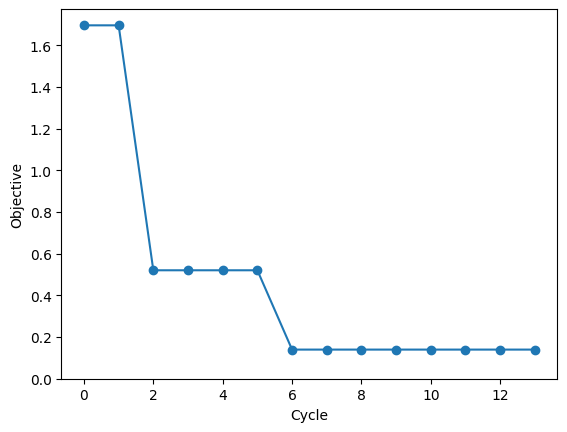

In [15]:
import matplotlib.pyplot as plt

print(objective_by_iter.keys())

fig, ax = plt.subplots()
tmp_history = [des.get_regret(max(objective_by_iter[1]))]
for i in range(1, CyclesNum):
    tmp_history.append(min(tmp_history[-1], des.get_regret(max(objective_by_iter[i]))))
ax.plot(range(CyclesNum), tmp_history, marker="o")
ax.set_xlabel("Cycle")
ax.set_ylim(0)
ax.set_ylabel("Objective")

In [16]:
# Save nested list object
import pickle
with open(out_dir / "objective_by_iter.pkl", "wb") as f:
    pickle.dump(objective_by_iter, f)
with open(out_dir / "sample_by_iter.pkl", "wb") as f:
    pickle.dump(sample_by_iter, f)